In [ ]:
'''libraries'''

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
import os
import pynucastro as pyna
#%matplotlib widget

In [2]:
rates_Reaclib_winnet=pyna.rates.library.Library(libfile="Nuclear_data\decays\Reaclib_18_9_20")

In [3]:
# Remove duplicate links from the library
rates_to_remove = []
for pair in rates_Reaclib_winnet.find_duplicate_links():
    for r in pair:
        if isinstance(r, pyna.rates.ReacLibRate):
            rates_to_remove.append(r)
for r in rates_to_remove:
    rates_Reaclib_winnet.remove_rate(r)

In [4]:

filter_alpha=pyna.RateFilter(products=['he4'],exact=False,max_reactants=1,max_products=2,filter_function=lambda r: r.Q>0)
rates_alpha=rates_Reaclib_winnet.filter(filter_alpha)
alpha=rates_alpha.get_rates()
alpha_rates=[]
for i in range(len(alpha)):
    if alpha[i].reactants[0].Z-alpha[i].products[0].Z-alpha[i].products[1].Z==0:
        alpha_rates.append(alpha[i])
   

In [5]:

filter_beta_minus=pyna.RateFilter(max_reactants=1,max_products=1,filter_function=lambda r: r.Q>0)
rates_beta_minus=rates_Reaclib_winnet.filter(filter_beta_minus)
beta=rates_beta_minus.get_rates()
Beta_minus_rates=[]
for i in range(len(beta)):
    if beta[i].reactants[0].N-beta[i].products[0].N==1:
        Beta_minus_rates.append(beta[i])
    

In [10]:
len(alpha_rates),len(Beta_minus_rates)

(1173, 4861)

In [6]:
iesb=[]
iesa=[]
for i in range(len(Beta_minus_rates)):
    if Beta_minus_rates[i].eval_deriv(1e8)!=0:
        iesb.append(Beta_minus_rates[i])
for i in range(len(alpha_rates)):
    if alpha_rates[i].eval_deriv(1e8)!=0:
        iesa.append(alpha_rates[i])

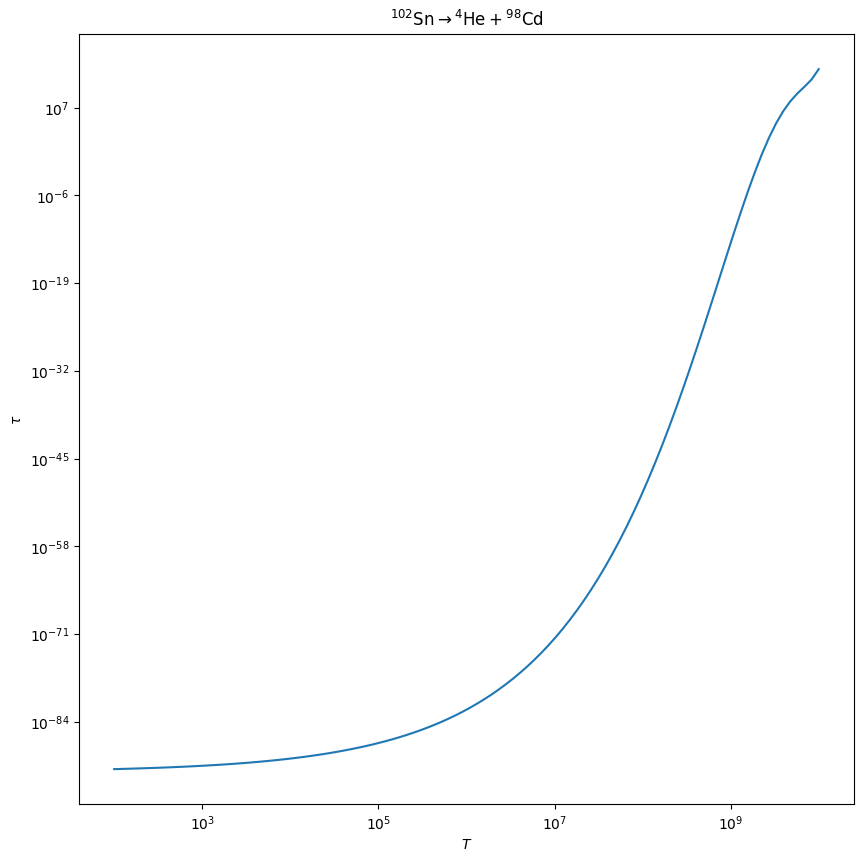

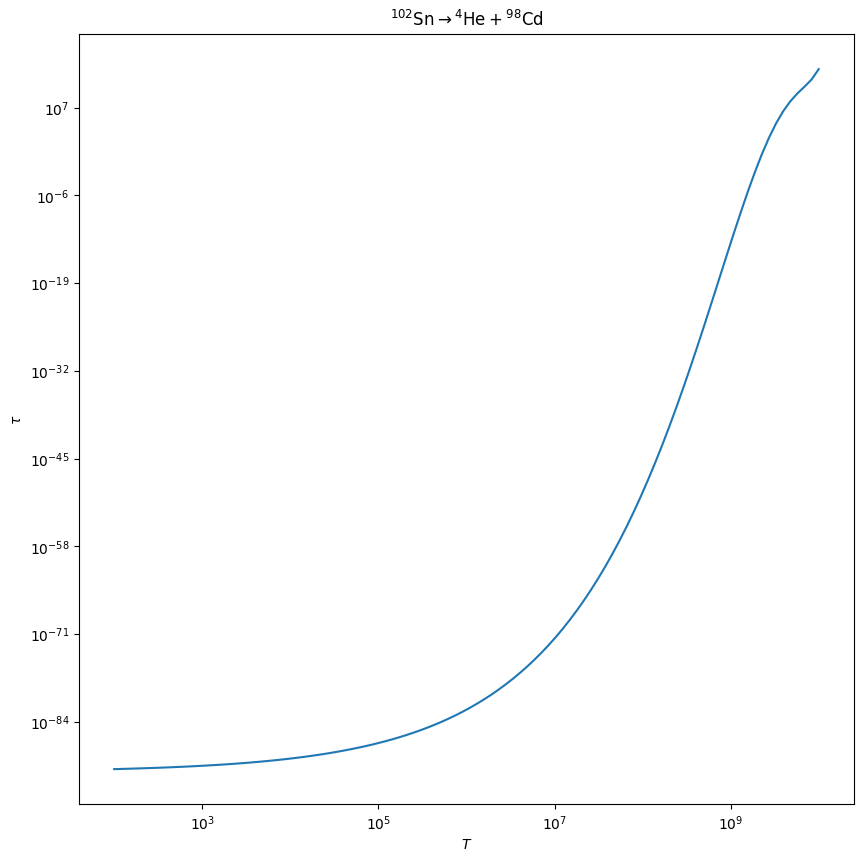

In [13]:
iesa[0].plot(Tmin=1e2,Tmax=1e10)